Found 191 images belonging to 4 classes.
1/1 [==============================] - 0s 79ms/step


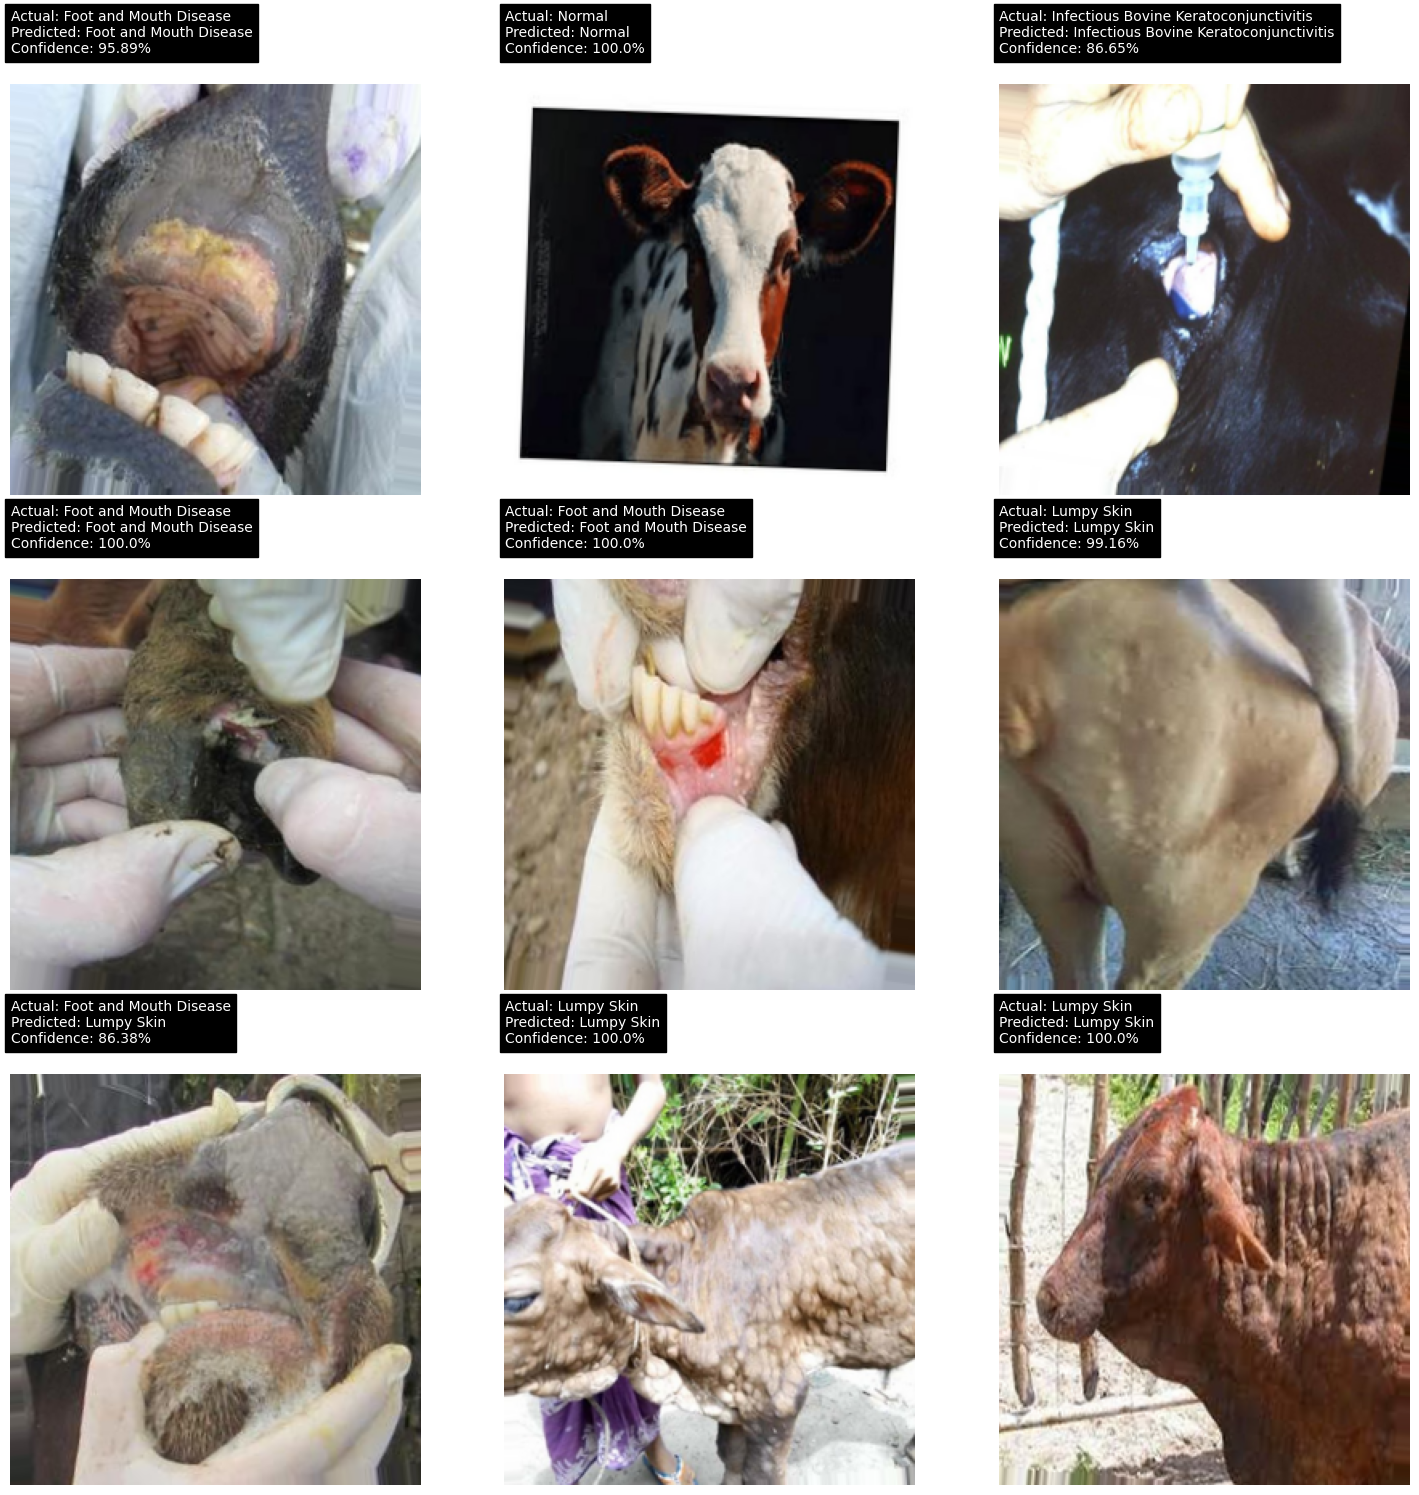

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing.image import ImageDataGenerator

# Load the model
model = tf.keras.models.load_model('/content/drive/MyDrive/4s.h5')

# Define the predict function with class_names as argument
def predict(model, img, class_names):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

# Define class names
class_names = ["Foot and Mouth Disease", "Infectious Bovine Keratoconjunctivitis", "Lumpy Skin", "Normal"]

# Define test data generator
test_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10
)

test_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/A simple model.v1i.folder/Data/test',
    target_size=(256,256),
    batch_size=32,
    class_mode='sparse'
)

# Visualize predictions on test images
plt.figure(figsize=(15, 15))
for images, labels in test_generator:
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.axis("off")

        # Make predictions
        predicted_class, confidence = predict(model, images[i], class_names)
        actual_class = class_names[int(labels[i])]

        # Prepare informative text
        text = f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%"

        # Add text to the image
        plt.text(0, -20, text, color='white', fontsize=10, ha='left', backgroundcolor='black')

    break  # Show only the first batch of images
plt.tight_layout()
plt.show()
